## 1. Setup — Kaggle credentials

## 2. Download raw dataset

In [1]:
import os
os.makedirs('/kaggle/working/results', exist_ok=True)
print('Kaggle working directories ready.')


Kaggle working directories ready.


In [2]:
!pip install -q imagehash

## 3. Preprocessing — inspect, deduplicate, split (Task 1 & 2)

In [3]:
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

RAW_DIR = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"  # VERIFY this matches your `!ls /kaggle/input/chest-xray-pneumonia/` output

def collect_all_images(raw_dir):
    filepaths, labels = [], []
    for split in ["train", "val", "test"]:
        for cls in ["NORMAL", "PNEUMONIA"]:
            folder = os.path.join(raw_dir, split, cls)
            if not os.path.isdir(folder):
                continue
            for fname in os.listdir(folder):
                if fname.lower().endswith((".jpeg", ".jpg", ".png")):
                    filepaths.append(os.path.join(folder, fname))
                    labels.append(cls)
    return filepaths, labels

filepaths, labels = collect_all_images(RAW_DIR)
print(f"Total images found: {len(filepaths)}")
print(f"NORMAL={labels.count('NORMAL')}, PNEUMONIA={labels.count('PNEUMONIA')}")

Total images found: 5856
NORMAL=1583, PNEUMONIA=4273


In [4]:
import imagehash
from PIL import Image

def dedupe(filepaths, labels):
    seen_hashes = {}
    keep_paths, keep_labels = [], []
    for fp, lb in zip(filepaths, labels):
        try:
            h = str(imagehash.phash(Image.open(fp)))
        except Exception as e:
            print(f"Skipping corrupted file {fp}: {e}")
            continue
        if h in seen_hashes:
            continue
        seen_hashes[h] = fp
        keep_paths.append(fp)
        keep_labels.append(lb)
    print(f"Removed {len(filepaths) - len(keep_paths)} duplicate/corrupted images")
    return keep_paths, keep_labels

filepaths, labels = dedupe(filepaths, labels)

Removed 32 duplicate/corrupted images


In [5]:
from sklearn.model_selection import train_test_split

label_ids = [0 if l == "NORMAL" else 1 for l in labels]

train_fp, temp_fp, train_lb, temp_lb = train_test_split(
    filepaths, label_ids, test_size=0.2, stratify=label_ids, random_state=42)

val_fp, test_fp, val_lb, test_lb = train_test_split(
    temp_fp, temp_lb, test_size=0.5, stratify=temp_lb, random_state=42)

for name, lb in [("train", train_lb), ("val", val_lb), ("test", test_lb)]:
    print(f"{name}: total={len(lb)} NORMAL={lb.count(0)} PNEUMONIA={lb.count(1)}")

train: total=4659 NORMAL=1263 PNEUMONIA=3396
val: total=582 NORMAL=158 PNEUMONIA=424
test: total=583 NORMAL=158 PNEUMONIA=425


In [6]:
s_train, s_val, s_test = set(train_fp), set(val_fp), set(test_fp)
assert not (s_train & s_val), "Leakage between train/val!"
assert not (s_train & s_test), "Leakage between train/test!"
assert not (s_val & s_test), "Leakage between val/test!"
print("No leakage between splits confirmed.")

No leakage between splits confirmed.


In [7]:
import shutil

def materialize_split(fp_list, lb_list, out_root, split_name):
    for fp, lb in zip(fp_list, lb_list):
        cls_name = "NORMAL" if lb == 0 else "PNEUMONIA"
        dest_dir = os.path.join(out_root, split_name, cls_name)
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy(fp, os.path.join(dest_dir, os.path.basename(fp)))

OUT_ROOT = "/kaggle/working/data_split"
materialize_split(train_fp, train_lb, OUT_ROOT, "train")
materialize_split(val_fp, val_lb, OUT_ROOT, "val")
materialize_split(test_fp, test_lb, OUT_ROOT, "test")
print(f"Split folders written to {OUT_ROOT}")

Split folders written to /kaggle/working/data_split


## 4. Data pipeline — normalization & augmentation (Task 3)

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
DATA_ROOT = "/kaggle/working/data_split"

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_ROOT}/train",
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_ROOT}/val",
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_ROOT}/test",
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds_raw.class_names
print("Classes:", class_names)

normalize = tf.keras.layers.Rescaling(1.0 / 255)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomBrightness(0.1),
])

def prep_train(image, label):
    image = normalize(image)
    image = augment(image, training=True)
    return image, label

def prep_eval(image, label):
    image = normalize(image)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.map(prep_train, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
val_ds = val_ds_raw.map(prep_eval, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds = test_ds_raw.map(prep_eval, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
print("Pipelines built.")

Found 4659 files belonging to 2 classes.


I0000 00:00:1789389995.606189      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789389995.609123      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 582 files belonging to 2 classes.
Found 583 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']
Pipelines built.


In [9]:
import numpy as np

train_labels_flat = np.concatenate([y.numpy() for _, y in train_ds_raw], axis=0).flatten()
n_normal = np.sum(train_labels_flat == 0)
n_pneumonia = np.sum(train_labels_flat == 1)
total = n_normal + n_pneumonia
class_weight = {0: total / (2 * n_normal), 1: total / (2 * n_pneumonia)}
print("Class weights:", class_weight)

Class weights: {0: np.float64(1.844418052256532), 1: np.float64(0.6859540636042403)}


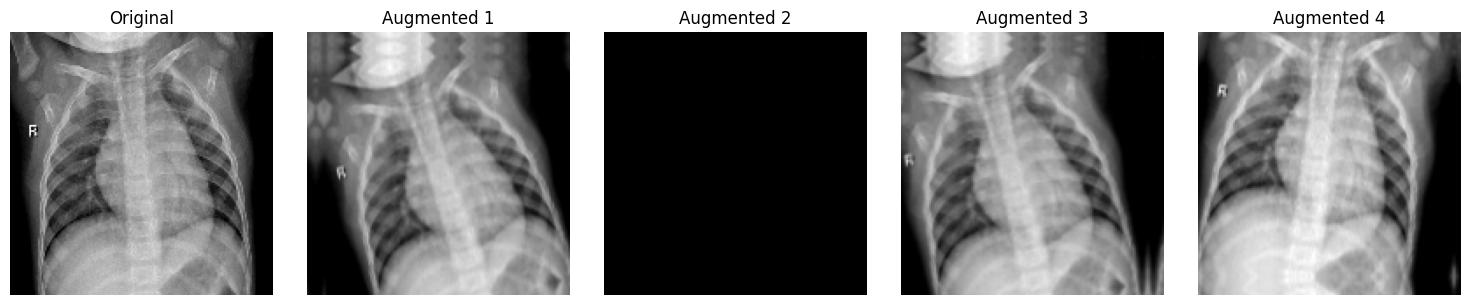

In [10]:
def show_before_after(dataset_raw):
    for images, labels in dataset_raw.take(1):
        img = images[0]
        fig, axes = plt.subplots(1, 5, figsize=(15, 3))
        axes[0].imshow(img.numpy().astype("uint8").squeeze(), cmap="gray")
        axes[0].set_title("Original"); axes[0].axis("off")
        norm_img = normalize(tf.expand_dims(img, 0))
        for i in range(1, 5):
            aug_img = augment(norm_img, training=True)[0]
            axes[i].imshow(aug_img.numpy().squeeze(), cmap="gray")
            axes[i].set_title(f"Augmented {i}"); axes[i].axis("off")
        plt.tight_layout()
        plt.savefig("/kaggle/working/augmentation_examples.png", dpi=150)
        plt.show()
show_before_after(train_ds_raw)

## 5. Primary model — custom CNN (Task 4)

In [11]:
from tensorflow.keras import layers, models, regularizers

def build_custom_cnn(input_shape=(150, 150, 1), dropout_rate=0.5, l2_lambda=1e-4):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding="same", kernel_regularizer=regularizers.l2(l2_lambda))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", kernel_regularizer=regularizers.l2(l2_lambda))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", kernel_regularizer=regularizers.l2(l2_lambda))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding="same", kernel_regularizer=regularizers.l2(l2_lambda))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda))(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(inputs, outputs, name="custom_cnn")

model = build_custom_cnn()
model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,785 (1.61 MB)

 Trainable params: 421,825 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
import pandas as pd

rows = []
for layer in model.layers:
    out_shape = layer.output.shape if hasattr(layer, "output") else "N/A"
    rows.append({
        "Layer (name)": layer.name,
        "Type": layer.__class__.__name__,
        "Output Shape": str(out_shape),
        "Param #": f"{layer.count_params():,}"
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print(f"\nTotal params: {model.count_params():,}")
print(f"Trainable params: {sum(tf.keras.backend.count_params(w) for w in model.trainable_weights):,}")

            Layer (name)                   Type         Output Shape Param #
           input_layer_1             InputLayer  (None, 150, 150, 1)       0
                  conv2d                 Conv2D (None, 150, 150, 32)     320
     batch_normalization     BatchNormalization (None, 150, 150, 32)     128
                   re_lu                   ReLU (None, 150, 150, 32)       0
           max_pooling2d           MaxPooling2D   (None, 75, 75, 32)       0
                conv2d_1                 Conv2D   (None, 75, 75, 64)  18,496
   batch_normalization_1     BatchNormalization   (None, 75, 75, 64)     256
                 re_lu_1                   ReLU   (None, 75, 75, 64)       0
         max_pooling2d_1           MaxPooling2D   (None, 37, 37, 64)       0
                conv2d_2                 Conv2D  (None, 37, 37, 128)  73,856
   batch_normalization_2     BatchNormalization  (None, 37, 37, 128)     512
                 re_lu_2                   ReLU  (None, 37, 37, 128)       0

## 6. Training pipeline (Task 6)

In [13]:
import time
tf.random.set_seed(42)
run_id = time.strftime("%Y%m%d_%H%M%S")

model = build_custom_cnn()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        f"/kaggle/working/results/custom_cnn_{run_id}.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1),
    tf.keras.callbacks.CSVLogger(f"/kaggle/working/results/history_{run_id}.csv"),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/50


2026-09-14 12:46:59.017094: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 12:46:59.165036: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  3/146 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.5122 - auc: 0.5041 - loss: 0.8979  

I0000 00:00:1789390023.225439      81 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4996 - auc: 0.5069 - loss: 0.8155

2026-09-14 12:47:17.964466: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 12:47:18.110016: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4996 - auc: 0.5069 - loss: 0.8153
Epoch 1: val_auc improved from None to 0.51093, saving model to /kaggle/working/results/custom_cnn_20260914_124651.keras

Epoch 1: finished saving model to /kaggle/working/results/custom_cnn_20260914_124651.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 34s 154ms/step - accuracy: 0.5040 - auc: 0.5035 - loss: 0.7916 - val_accuracy: 0.2715 - val_auc: 0.5109 - val_loss: 0.7721
Epoch 2/50
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4995 - auc: 0.5028 - loss: 0.7677
Epoch 2: val_auc did not improve from 0.51093
146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4995 - auc: 0.5017 - loss: 0.7580 - val_accuracy: 0.2715 - val_auc: 0.4858 - val_loss: 0.7623
Epoch 3/50
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4959 - auc: 0.5070 - loss: 0.7560
Epoch 3: val_auc improved from 0.51093 to 0.76491, saving model to /kaggle/working/results/custom_cnn_20260914_124651.keras

Epoch 3: finished sav

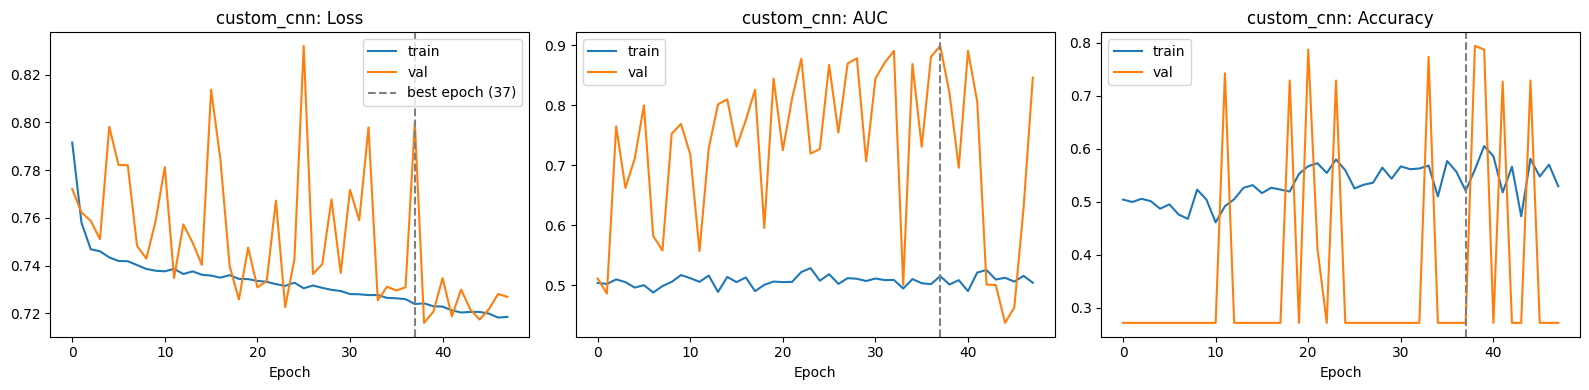

Best epoch: 37, val_auc: 0.8993


In [14]:
import matplotlib.pyplot as plt
import os

os.makedirs("/kaggle/working/results", exist_ok=True)
best_epoch = int(np.argmax(history.history["val_auc"]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].axvline(best_epoch, color="gray", linestyle="--", label=f"best epoch ({best_epoch})")
axes[0].set_title("custom_cnn: Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history.history["auc"], label="train")
axes[1].plot(history.history["val_auc"], label="val")
axes[1].axvline(best_epoch, color="gray", linestyle="--")
axes[1].set_title("custom_cnn: AUC"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(history.history["accuracy"], label="train")
axes[2].plot(history.history["val_accuracy"], label="val")
axes[2].axvline(best_epoch, color="gray", linestyle="--")
axes[2].set_title("custom_cnn: Accuracy"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig(f"/kaggle/working/results/custom_cnn_curves_{run_id}.png", dpi=150)
plt.show()

print(f"Best epoch: {best_epoch}, val_auc: {history.history['val_auc'][best_epoch]:.4f}")

## 7. Model diagnostics — threshold & calibration check

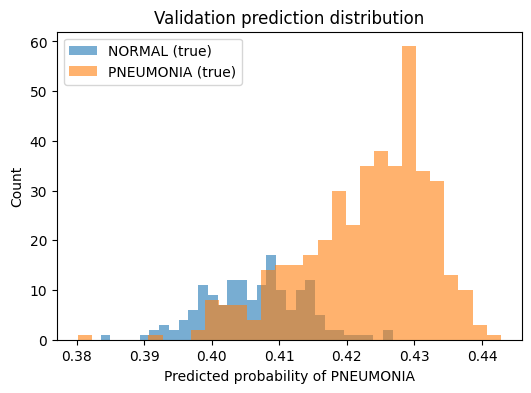

Best threshold (max F1 on val): 0.41

--- Threshold 0.50 (default) ---
[[158   0]
 [424   0]]
              precision    recall  f1-score   support

      NORMAL       0.27      1.00      0.43       158
   PNEUMONIA       0.00      0.00      0.00       424

    accuracy                           0.27       582
   macro avg       0.14      0.50      0.21       582
weighted avg       0.07      0.27      0.12       582


--- Threshold 0.41 (optimal) ---
[[110  48]
 [ 47 377]]
              precision    recall  f1-score   support

      NORMAL       0.70      0.70      0.70       158
   PNEUMONIA       0.89      0.89      0.89       424

    accuracy                           0.84       582
   macro avg       0.79      0.79      0.79       582
weighted avg       0.84      0.84      0.84       582



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, f1_score

def get_labels_and_probs(model, dataset):
    y_true, y_prob = [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).flatten()
        y_prob.extend(probs)
        y_true.extend(labels.numpy().flatten())
    return np.array(y_true), np.array(y_prob)

y_val_true, y_val_prob = get_labels_and_probs(model, val_ds)

plt.figure(figsize=(6, 4))
plt.hist(y_val_prob[y_val_true == 0], bins=30, alpha=0.6, label="NORMAL (true)")
plt.hist(y_val_prob[y_val_true == 1], bins=30, alpha=0.6, label="PNEUMONIA (true)")
plt.xlabel("Predicted probability of PNEUMONIA")
plt.ylabel("Count")
plt.legend()
plt.title("Validation prediction distribution")
plt.savefig("/kaggle/working/results/custom_cnn_prob_histogram.png", dpi=150)
plt.show()

thresholds = np.linspace(0.01, 0.99, 99)
f1_scores = [f1_score(y_val_true, (y_val_prob >= t).astype(int)) for t in thresholds]
CUSTOM_CNN_THRESHOLD = thresholds[np.argmax(f1_scores)]
print(f"Best threshold (max F1 on val): {CUSTOM_CNN_THRESHOLD:.2f}")

for label, t in [("0.50 (default)", 0.5), (f"{CUSTOM_CNN_THRESHOLD:.2f} (optimal)", CUSTOM_CNN_THRESHOLD)]:
    preds = (y_val_prob >= t).astype(int)
    print(f"\n--- Threshold {label} ---")
    print(confusion_matrix(y_val_true, preds))
    print(classification_report(y_val_true, preds, target_names=class_names))

In [16]:
import shutil
import os

# Ensure the results directory exists, though it should from previous steps
os.makedirs("/kaggle/working/results", exist_ok=True)

# Copy the best performing model to the final name
shutil.copy(f"/kaggle/working/results/custom_cnn_{run_id}.keras", "/kaggle/working/results/custom_cnn_FINAL.keras")

print(f"Copied /kaggle/working/results/custom_cnn_{run_id}.keras to /kaggle/working/results/custom_cnn_FINAL.keras")

Copied /kaggle/working/results/custom_cnn_20260914_124651.keras to /kaggle/working/results/custom_cnn_FINAL.keras


## 8. Comparison models — VGG16 & ResNet50, frozen and fine-tuned (Task 5)

In [17]:
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

PRETRAINED_IMG_SIZE = (224, 224)

def make_pretrained_datasets(preprocess_fn):
    train_raw = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_ROOT}/train", labels="inferred", label_mode="binary",
        color_mode="rgb", image_size=PRETRAINED_IMG_SIZE, batch_size=BATCH_SIZE,
        shuffle=True, seed=42)
    val_raw = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_ROOT}/val", labels="inferred", label_mode="binary",
        color_mode="rgb", image_size=PRETRAINED_IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)
    test_raw = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_ROOT}/test", labels="inferred", label_mode="binary",
        color_mode="rgb", image_size=PRETRAINED_IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

    def prep_train_pt(image, label):
        image = augment(image, training=True)
        image = preprocess_fn(image)
        return image, label

    def prep_eval_pt(image, label):
        return preprocess_fn(image), label

    train = train_raw.map(prep_train_pt, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    val = val_raw.map(prep_eval_pt, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    test = test_raw.map(prep_eval_pt, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    return train, val, test

def build_transfer_model(base_class, name, trainable=False, fine_tune_at=None, dropout_rate=0.5):
    base = base_class(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
    base.trainable = trainable
    if trainable and fine_tune_at is not None:
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base(inputs, training=trainable)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inputs, outputs, name=name)

def train_variant(m, train_ds_var, val_ds_var, name, epochs=15, lr=1e-4, patience=5):
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    cb = [
        tf.keras.callbacks.ModelCheckpoint(f"/kaggle/working/results/{name}_best.keras", monitor="val_auc",
                                            mode="max", save_best_only=True, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=patience,
                                          restore_best_weights=True, verbose=1),
    ]
    return m.fit(train_ds_var, validation_data=val_ds_var, epochs=epochs,
                 class_weight=class_weight, callbacks=cb, verbose=1)

transfer_histories = {}

In [18]:
# VGG16 - frozen backbone (feature extraction only)
train_vgg, val_vgg, test_vgg = make_pretrained_datasets(vgg_preprocess)

vgg_frozen = build_transfer_model(VGG16, "vgg16_frozen", trainable=False)
transfer_histories["vgg16_frozen"] = train_variant(vgg_frozen, train_vgg, val_vgg, "vgg16_frozen", epochs=15, lr=1e-3)

Found 4659 files belonging to 2 classes.
Found 582 files belonging to 2 classes.
Found 583 files belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 81s 432ms/step - accuracy: 0.8362 - auc: 0.9137 - loss: 0.3991 - val_accuracy: 0.8918 - val_auc: 0.9755 - val_loss: 0.2535
Epoch 2/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 48s 322ms/step - accuracy: 0.8927 - auc: 0.9534 - loss: 0.2767 - val_accuracy: 0.8952 - val_auc: 0.9763 - val_loss: 0.2499
Epoch 3/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 46s 307ms/step - accuracy: 0.9083 - auc: 0.9663 - loss: 0.2347 - val_accuracy: 0.9038 - val_auc: 0.9809 - val_loss: 0.2209
Epoch 4/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 46s 312ms/step - accuracy: 0.9174 - auc: 0.9726 - loss: 0.2113 - val_accuracy: 0.9399 - val_auc: 0.9830 - val_loss: 0.1635
Epoch 5/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 82s 313ms/step - accuracy: 0.9174 - auc: 0.9719 - loss: 0.2132 - val_accuracy: 0.9381 - val_auc: 0.9831 - val_loss: 0.1864
Epoch 6/15
14

In [19]:
# VGG16 - fine-tuned (unfreeze the last few conv blocks, train at a low LR)
vgg_finetune = build_transfer_model(VGG16, "vgg16_finetuned", trainable=True, fine_tune_at=15)
transfer_histories["vgg16_finetuned"] = train_variant(vgg_finetune, train_vgg, val_vgg, "vgg16_finetuned", epochs=10, lr=1e-5)

Epoch 1/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 58s 341ms/step - accuracy: 0.7598 - auc: 0.8483 - loss: 0.5519 - val_accuracy: 0.8471 - val_auc: 0.9708 - val_loss: 0.4089
Epoch 2/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 48s 319ms/step - accuracy: 0.9041 - auc: 0.9639 - loss: 0.2428 - val_accuracy: 0.8832 - val_auc: 0.9752 - val_loss: 0.3461
Epoch 3/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 48s 319ms/step - accuracy: 0.9257 - auc: 0.9764 - loss: 0.1947 - val_accuracy: 0.8780 - val_auc: 0.9804 - val_loss: 0.3206
Epoch 4/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 48s 320ms/step - accuracy: 0.9307 - auc: 0.9804 - loss: 0.1772 - val_accuracy: 0.9364 - val_auc: 0.9836 - val_loss: 0.1955
Epoch 5/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 81s 313ms/step - accuracy: 0.9436 - auc: 0.9840 - loss: 0.1539 - val_accuracy: 0.9089 - val_auc: 0.9837 - val_loss: 0.2646
Epoch 6/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 46s 312ms/step - accuracy: 0.9457 - auc: 0.9867 - loss: 0.1438 - val_accuracy: 0.9485 - val_auc: 0.9862 - val_loss: 0.1401
Epoch 7/10
146/146 ━━━

In [20]:
# ResNet50 - frozen backbone
train_resnet, val_resnet, test_resnet = make_pretrained_datasets(resnet_preprocess)

resnet_frozen = build_transfer_model(ResNet50, "resnet50_frozen", trainable=False)
transfer_histories["resnet50_frozen"] = train_variant(resnet_frozen, train_resnet, val_resnet, "resnet50_frozen", epochs=15, lr=1e-3)

Found 4659 files belonging to 2 classes.
Found 582 files belonging to 2 classes.
Found 583 files belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 72s 382ms/step - accuracy: 0.8714 - auc: 0.9418 - loss: 0.3145 - val_accuracy: 0.9244 - val_auc: 0.9799 - val_loss: 0.1866
Epoch 2/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 45s 301ms/step - accuracy: 0.9105 - auc: 0.9700 - loss: 0.2212 - val_accuracy: 0.9347 - val_auc: 0.9837 - val_loss: 0.1580
Epoch 3/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 45s 304ms/step - accuracy: 0.9208 - auc: 0.9767 - loss: 0.1943 - val_accuracy: 0.9416 - val_auc: 0.9856 - val_loss: 0.1570
Epoch 4/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 45s 300ms/step - accuracy: 0.9281 - auc: 0.9792 - loss: 0.1818 - val_accuracy: 0.9519 - val_auc: 0.9856 - val_loss: 0.1298
Epoch 5/15
146/146 ━━━━━━━━━━━━━━━━━━━━ 45s 305ms/step - accuracy: 0.9296 - auc: 0.9801 - loss: 0.1802 - val_accuracy: 0.9502 - val_auc: 0.9869 - val_loss: 0.1282
Epoch 6/15
14

In [21]:
# ResNet50 - fine-tuned (unfreeze roughly the last third of layers)
resnet_finetune = build_transfer_model(ResNet50, "resnet50_finetuned", trainable=True, fine_tune_at=140)
transfer_histories["resnet50_finetuned"] = train_variant(resnet_finetune, train_resnet, val_resnet, "resnet50_finetuned", epochs=10, lr=1e-5)

Epoch 1/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 82s 399ms/step - accuracy: 0.7815 - auc: 0.8798 - loss: 0.4431 - val_accuracy: 0.9210 - val_auc: 0.9696 - val_loss: 0.1965
Epoch 2/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 46s 309ms/step - accuracy: 0.9165 - auc: 0.9725 - loss: 0.2208 - val_accuracy: 0.9244 - val_auc: 0.9779 - val_loss: 0.1857
Epoch 3/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 82s 313ms/step - accuracy: 0.9360 - auc: 0.9813 - loss: 0.1739 - val_accuracy: 0.9364 - val_auc: 0.9814 - val_loss: 0.1798
Epoch 4/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 47s 314ms/step - accuracy: 0.9455 - auc: 0.9863 - loss: 0.1480 - val_accuracy: 0.9467 - val_auc: 0.9847 - val_loss: 0.1508
Epoch 5/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 46s 311ms/step - accuracy: 0.9466 - auc: 0.9871 - loss: 0.1410 - val_accuracy: 0.9485 - val_auc: 0.9848 - val_loss: 0.1515
Epoch 6/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 46s 311ms/step - accuracy: 0.9545 - auc: 0.9911 - loss: 0.1193 - val_accuracy: 0.9433 - val_auc: 0.9851 - val_loss: 0.1694
Epoch 7/10
146/146 ━━━

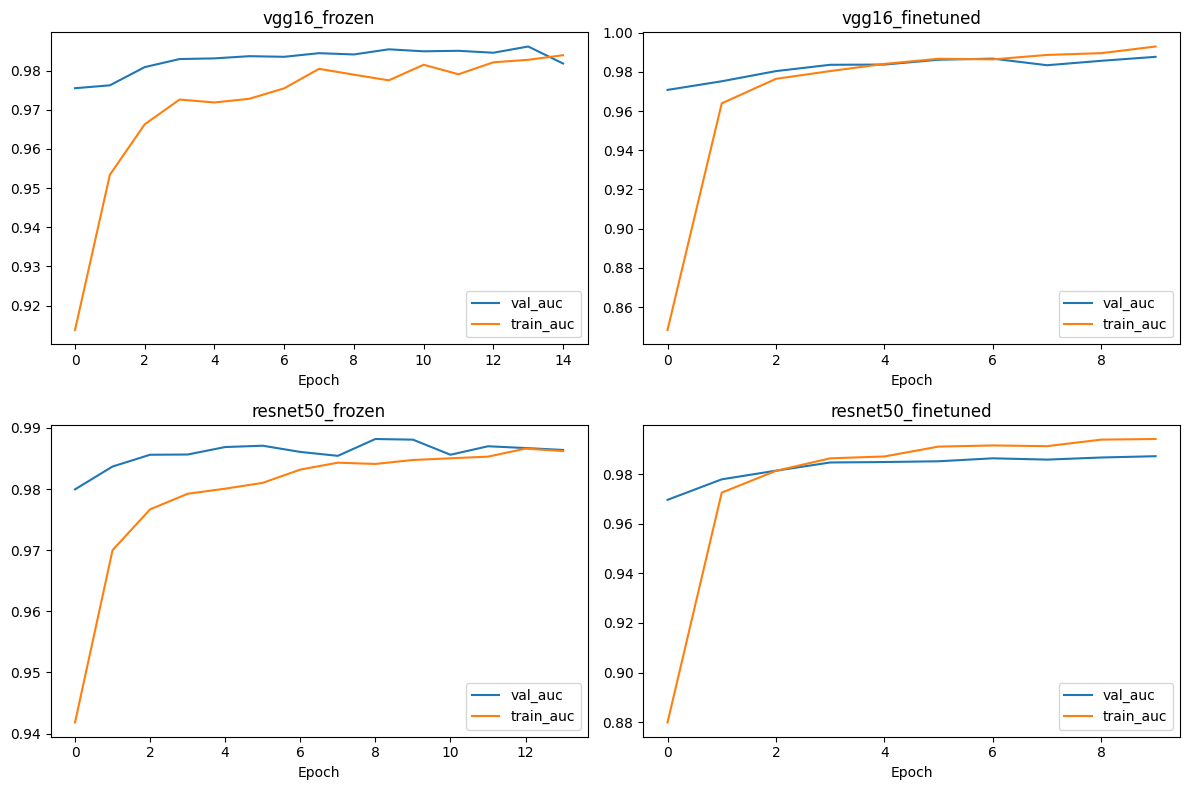

In [22]:
# Plot training/validation curves for all 4 comparison models
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, h) in zip(axes.flat, transfer_histories.items()):
    ax.plot(h.history["val_auc"], label="val_auc")
    ax.plot(h.history["auc"], label="train_auc")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/results/transfer_models_curves.png", dpi=150)
plt.show()

## 9. Hyperparameter tuning & data-volume study (Task 7)

**Scope note for the report:** a full cross-product grid search over all 8 requested hyperparameters (batch size, LR, epochs, dropout, patience, L1/L2, normalization, augmentation policy) would require thousands of training runs, which isn't feasible on Colab's free tier in the assignment timeframe. The approach below grid-searches the 4 hyperparameters with the largest expected effect (batch size, learning rate, dropout, L2 lambda) jointly, then tests normalization scheme, augmentation policy, and early-stopping patience as one-factor-at-a-time ablations on top of the best config found. State this scope decision explicitly in Section IV of the report.

In [23]:
import itertools
import pandas as pd
import gc

grid = {
    "batch_size": [16, 32],
    "learning_rate": [1e-3, 1e-4],
    "dropout_rate": [0.3, 0.5],
    "l2_lambda": [1e-4, 1e-3],
}

grid_results = []
combos = list(itertools.product(*grid.values()))
GRID_EPOCHS = 6
print(f"Running {len(combos)} grid search combinations ({GRID_EPOCHS} epochs each)...")

for i, (bs, lr, dr, l2) in enumerate(combos):
    print(f"\n--- Combo {i+1}/{len(combos)}: bs={bs}, lr={lr}, dropout={dr}, l2={l2} ---")
    tf.keras.backend.clear_session()
    gc.collect()

    try:
        tr_ds = (train_ds_raw.unbatch().batch(bs)
                  .map(prep_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE))
        va_ds = (val_ds_raw.unbatch().batch(bs)
                  .map(prep_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE))

        m = build_custom_cnn(dropout_rate=dr, l2_lambda=l2)
        m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                   loss="binary_crossentropy",
                   metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
        h = m.fit(tr_ds, validation_data=va_ds, epochs=GRID_EPOCHS,
                   class_weight=class_weight, verbose=0)
        best_val_auc = max(h.history["val_auc"])

        grid_results.append({"batch_size": bs, "learning_rate": lr, "dropout_rate": dr,
                              "l2_lambda": l2, "best_val_auc": best_val_auc})
        print(f"bs={bs}, lr={lr}, dropout={dr}, l2={l2} -> val_auc={best_val_auc:.4f}")
        del m, h, tr_ds, va_ds

    except Exception as e:
        print(f"Combo {i+1} FAILED: {e}")
        grid_results.append({"batch_size": bs, "learning_rate": lr, "dropout_rate": dr,
                              "l2_lambda": l2, "best_val_auc": None})
        continue

grid_df = pd.DataFrame(grid_results).sort_values("best_val_auc", ascending=False)
print("\n", grid_df.to_string(index=False))
grid_df.to_csv("/kaggle/working/results/grid_search_results.csv", index=False)

best_config = grid_df.iloc[0].to_dict()
print("\nBest configuration:", best_config)


Running 16 grid search combinations (6 epochs each)...

--- Combo 1/16: bs=16, lr=0.001, dropout=0.3, l2=0.0001 ---


2026-09-14 13:36:08.083135: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 13:36:08.228213: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 13:36:27.141834: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 13:36:27.284105: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/e

bs=16, lr=0.001, dropout=0.3, l2=0.0001 -> val_auc=0.6594

--- Combo 2/16: bs=16, lr=0.001, dropout=0.3, l2=0.001 ---
bs=16, lr=0.001, dropout=0.3, l2=0.001 -> val_auc=0.5000

--- Combo 3/16: bs=16, lr=0.001, dropout=0.5, l2=0.0001 ---
bs=16, lr=0.001, dropout=0.5, l2=0.0001 -> val_auc=0.5671

--- Combo 4/16: bs=16, lr=0.001, dropout=0.5, l2=0.001 ---
bs=16, lr=0.001, dropout=0.5, l2=0.001 -> val_auc=0.5236

--- Combo 5/16: bs=16, lr=0.0001, dropout=0.3, l2=0.0001 ---
bs=16, lr=0.0001, dropout=0.3, l2=0.0001 -> val_auc=0.7194

--- Combo 6/16: bs=16, lr=0.0001, dropout=0.3, l2=0.001 ---
bs=16, lr=0.0001, dropout=0.3, l2=0.001 -> val_auc=0.7293

--- Combo 7/16: bs=16, lr=0.0001, dropout=0.5, l2=0.0001 ---
bs=16, lr=0.0001, dropout=0.5, l2=0.0001 -> val_auc=0.7240

--- Combo 8/16: bs=16, lr=0.0001, dropout=0.5, l2=0.001 ---
bs=16, lr=0.0001, dropout=0.5, l2=0.001 -> val_auc=0.7550

--- Combo 9/16: bs=32, lr=0.001, dropout=0.3, l2=0.0001 ---
bs=32, lr=0.001, dropout=0.3, l2=0.0001 -> val_a

In [24]:
import gc

# Ablation: normalization scheme (0-1 rescale vs. per-image standardization) and augmentation on/off,
# using the best hyperparameters found above.

def make_ablation_ds(use_std_norm, use_augmentation):
    def _norm(image):
        return tf.image.per_image_standardization(image) if use_std_norm else normalize(image)

    def _prep_train(image, label):
        image = _norm(image)
        if use_augmentation:
            image = augment(image, training=True)
        return image, label

    def _prep_eval(image, label):
        return _norm(image), label

    tr = train_ds_raw.map(_prep_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    va = val_ds_raw.map(_prep_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    return tr, va

ablation_results = []
for use_std_norm in [False, True]:
    for use_aug in [False, True]:
        tf.keras.backend.clear_session()
        gc.collect()

        tr, va = make_ablation_ds(use_std_norm, use_aug)
        m = build_custom_cnn(dropout_rate=best_config["dropout_rate"], l2_lambda=best_config["l2_lambda"])
        m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_config["learning_rate"]),
                  loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
        h = m.fit(tr, validation_data=va, epochs=6, class_weight=class_weight, verbose=0)
        ablation_results.append({
            "normalization": "standardization" if use_std_norm else "rescale_0_1",
            "augmentation": use_aug,
            "best_val_auc": max(h.history["val_auc"])
        })
        print(ablation_results[-1])
        del m, h, tr, va

ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv("/kaggle/working/results/ablation_results.csv", index=False)
print("\n", ablation_df.to_string(index=False))


{'normalization': 'rescale_0_1', 'augmentation': False, 'best_val_auc': 0.9803409576416016}
{'normalization': 'rescale_0_1', 'augmentation': True, 'best_val_auc': 0.8522733449935913}
{'normalization': 'standardization', 'augmentation': False, 'best_val_auc': 0.9833412766456604}
{'normalization': 'standardization', 'augmentation': True, 'best_val_auc': 0.8619163632392883}

   normalization  augmentation  best_val_auc
    rescale_0_1         False      0.980341
    rescale_0_1          True      0.852273
standardization         False      0.983341
standardization          True      0.861916


In [25]:
import gc

# Ablation: early-stopping patience, using the best hyperparameters, on the real (150x150) pipeline
patience_results = []
for patience in [5, 10, 15]:
    tf.keras.backend.clear_session()
    gc.collect()

    m = build_custom_cnn(dropout_rate=best_config["dropout_rate"], l2_lambda=best_config["l2_lambda"])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_config["learning_rate"]),
              loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    cb = [tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=patience,
                                            restore_best_weights=True, verbose=0)]
    h = m.fit(train_ds, validation_data=val_ds, epochs=50, class_weight=class_weight, callbacks=cb, verbose=0)
    patience_results.append({"patience": patience, "epochs_run": len(h.history["loss"]),
                              "best_val_auc": max(h.history["val_auc"])})
    print(patience_results[-1])
    del m, h

patience_df = pd.DataFrame(patience_results)
patience_df.to_csv("/kaggle/working/results/patience_ablation.csv", index=False)
print("\n", patience_df.to_string(index=False))


{'patience': 5, 'epochs_run': 14, 'best_val_auc': 0.8868446946144104}
{'patience': 10, 'epochs_run': 34, 'best_val_auc': 0.9097430109977722}
{'patience': 15, 'epochs_run': 30, 'best_val_auc': 0.9152809381484985}

  patience  epochs_run  best_val_auc
        5          14      0.886845
       10          34      0.909743
       15          30      0.915281


Found 1164 files belonging to 2 classes.


2026-09-14 14:19:30.354841: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 14:19:30.499132: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


{'data_fraction': 0.25, 'n_train_images': 1164, 'best_val_auc': 0.8420557379722595}
Found 2329 files belonging to 2 classes.


2026-09-14 14:21:45.403390: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 14:21:45.549902: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


{'data_fraction': 0.5, 'n_train_images': 2329, 'best_val_auc': 0.8375030159950256}
Found 3494 files belonging to 2 classes.


2026-09-14 14:24:21.746224: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 14:24:21.888954: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


{'data_fraction': 0.75, 'n_train_images': 3494, 'best_val_auc': 0.7086817026138306}
Found 4659 files belonging to 2 classes.
{'data_fraction': 1.0, 'n_train_images': 4659, 'best_val_auc': 0.7917139530181885}


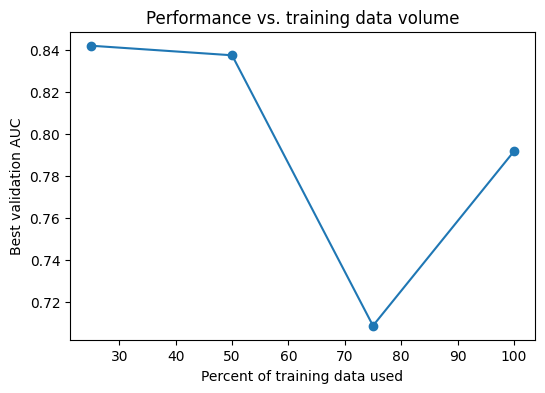

In [26]:
# Data-volume study: retrain on 25/50/75/100% of the training data
data_fractions = [0.25, 0.5, 0.75, 1.0]
volume_results = []
n_train_total = len(train_fp)

for frac in data_fractions:
    n_subset = int(n_train_total * frac)
    sub_fp, sub_lb = train_fp[:n_subset], train_lb[:n_subset]

    subset_root = f"/kaggle/working/data_split_subset_{int(frac*100)}"
    materialize_split(sub_fp, sub_lb, subset_root, "train")

    sub_train_raw = tf.keras.utils.image_dataset_from_directory(
        f"{subset_root}/train", labels="inferred", label_mode="binary",
        color_mode="grayscale", image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=42)
    sub_train_ds = sub_train_raw.map(prep_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

    m = build_custom_cnn(dropout_rate=best_config["dropout_rate"], l2_lambda=best_config["l2_lambda"])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_config["learning_rate"]),
              loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    cb = [tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8,
                                            restore_best_weights=True, verbose=0)]
    h = m.fit(sub_train_ds, validation_data=val_ds, epochs=30, class_weight=class_weight, callbacks=cb, verbose=0)

    volume_results.append({"data_fraction": frac, "n_train_images": n_subset,
                            "best_val_auc": max(h.history["val_auc"])})
    print(volume_results[-1])

volume_df = pd.DataFrame(volume_results)
volume_df.to_csv("/kaggle/working/results/data_volume_results.csv", index=False)

plt.figure(figsize=(6, 4))
plt.plot(volume_df["data_fraction"] * 100, volume_df["best_val_auc"], marker="o")
plt.xlabel("Percent of training data used")
plt.ylabel("Best validation AUC")
plt.title("Performance vs. training data volume")
plt.savefig("/kaggle/working/results/data_volume_curve.png", dpi=150)
plt.show()

## 10. Evaluation across all models (Task 8)

In [27]:
def evaluate_model_on_test(m, dataset, threshold=0.5):
    y_true, y_prob = get_labels_and_probs(m, dataset)
    y_pred = (y_prob >= threshold).astype(int)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    auc_score = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    return {
        "accuracy": report["accuracy"],
        "precision_macro": report["macro avg"]["precision"],
        "recall_macro": report["macro avg"]["recall"],
        "f1_macro": report["macro avg"]["f1-score"],
        "auc": auc_score,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_prob": y_prob,
    }

all_models_eval = {
    "custom_cnn": evaluate_model_on_test(model, test_ds, threshold=CUSTOM_CNN_THRESHOLD),
    "vgg16_frozen": evaluate_model_on_test(vgg_frozen, test_vgg),
    "vgg16_finetuned": evaluate_model_on_test(vgg_finetune, test_vgg),
    "resnet50_frozen": evaluate_model_on_test(resnet_frozen, test_resnet),
    "resnet50_finetuned": evaluate_model_on_test(resnet_finetune, test_resnet),
}

comparison_rows = [{
    "Model": name,
    "Accuracy": round(res["accuracy"], 4),
    "Precision (macro)": round(res["precision_macro"], 4),
    "Recall (macro)": round(res["recall_macro"], 4),
    "F1 (macro)": round(res["f1_macro"], 4),
    "AUC": round(res["auc"], 4),
} for name, res in all_models_eval.items()]

comparison_df = pd.DataFrame(comparison_rows).sort_values("AUC", ascending=False)
comparison_df.to_csv("/kaggle/working/results/model_comparison.csv", index=False)
print(comparison_df.to_string(index=False))

             Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)    AUC
resnet50_finetuned    0.9503             0.9244          0.9599      0.9397 0.9976
   vgg16_finetuned    0.9365             0.9058          0.9525      0.9243 0.9957
   resnet50_frozen    0.9451             0.9181          0.9544      0.9336 0.9956
      vgg16_frozen    0.9365             0.9058          0.9525      0.9243 0.9934
        custom_cnn    0.8576             0.8191          0.8228      0.8209 0.9208


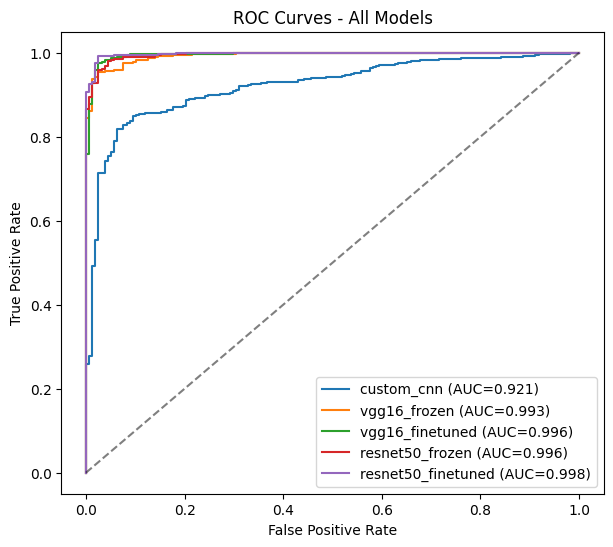

In [28]:
# ROC curves - all models on one plot
plt.figure(figsize=(7, 6))
for name, res in all_models_eval.items():
    fpr, tpr, _ = roc_curve(res["y_true"], res["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models")
plt.legend()
plt.savefig("/kaggle/working/results/roc_curves_all_models.png", dpi=150)
plt.show()

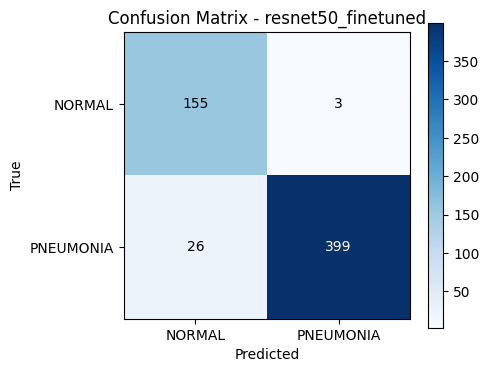

In [29]:
# Confusion matrix heatmap for the best-performing model
best_model_name = comparison_df.iloc[0]["Model"]
best_cm = all_models_eval[best_model_name]["confusion_matrix"]

plt.figure(figsize=(5, 4))
plt.imshow(best_cm, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
for i in range(2):
    for j in range(2):
        plt.text(j, i, best_cm[i, j], ha="center", va="center",
                  color="white" if best_cm[i, j] > best_cm.max() / 2 else "black")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("/kaggle/working/results/confusion_matrix_best_model.png", dpi=150)
plt.show()

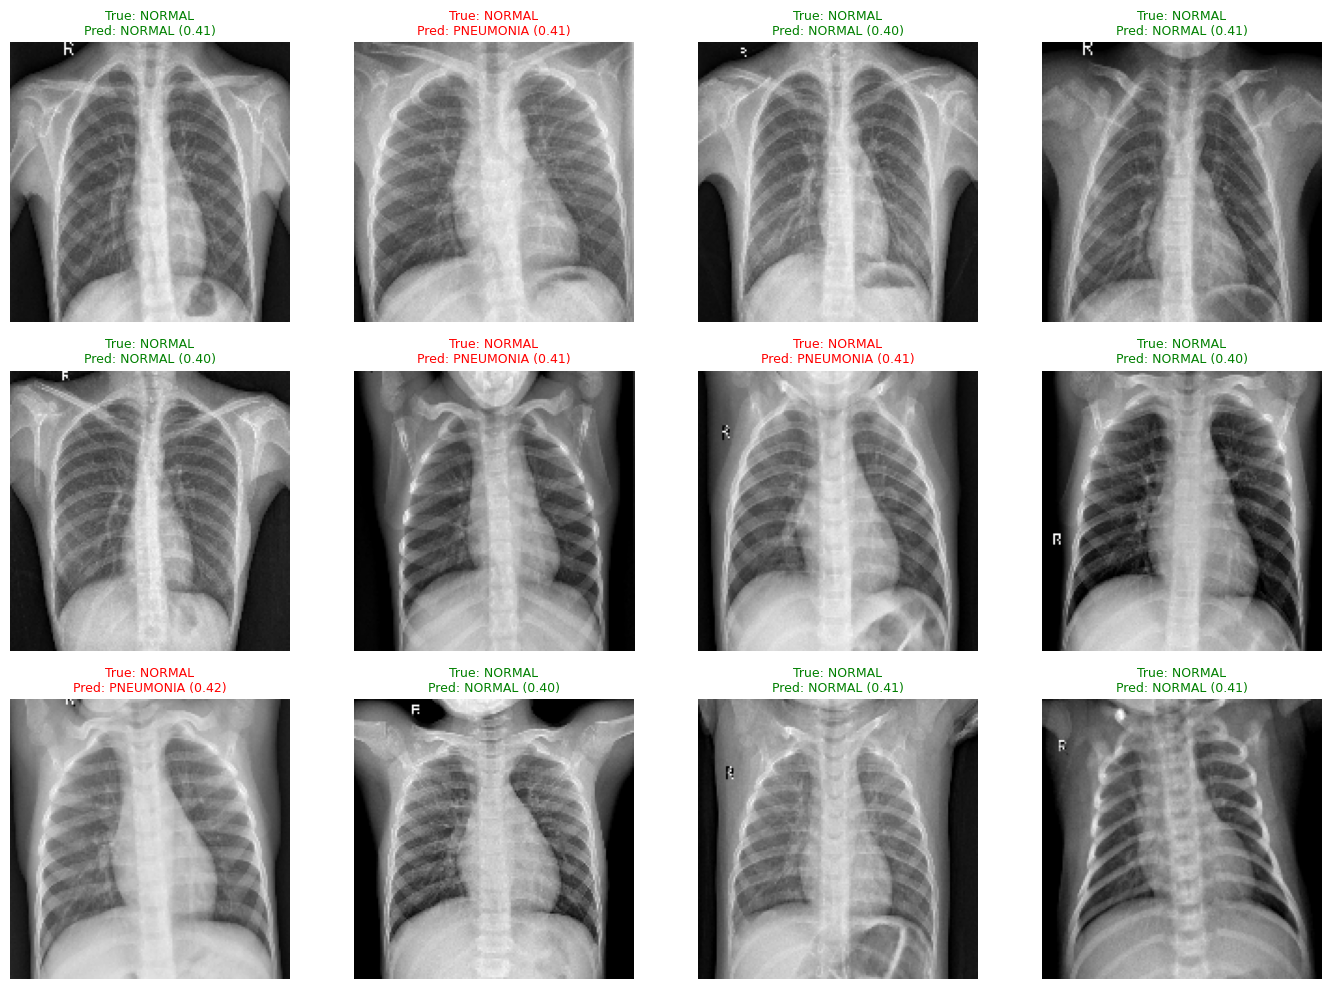

In [30]:
# Sample predictions grid (correct AND incorrect, color-coded)
def show_sample_predictions(m, dataset, threshold=0.5, n=12):
    images, labels = next(iter(dataset))
    probs = m.predict(images, verbose=0).flatten()
    preds = (probs >= threshold).astype(int)

    plt.figure(figsize=(14, 10))
    for i in range(min(n, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        img = images[i].numpy()
        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            disp = img - img.min()
            disp = disp / (disp.max() + 1e-8)
            plt.imshow(disp)
        true_lb = int(labels[i].numpy()[0])
        pred_lb = preds[i]
        color = "green" if true_lb == pred_lb else "red"
        plt.title(f"True: {class_names[true_lb]}\nPred: {class_names[pred_lb]} ({probs[i]:.2f})",
                   color=color, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.savefig("/kaggle/working/results/sample_predictions.png", dpi=150)
    plt.show()

show_sample_predictions(model, test_ds, threshold=CUSTOM_CNN_THRESHOLD)

## 11. Error analysis (Task 9)

Found 12 misclassified samples shown below (need >=10 for Task 9)


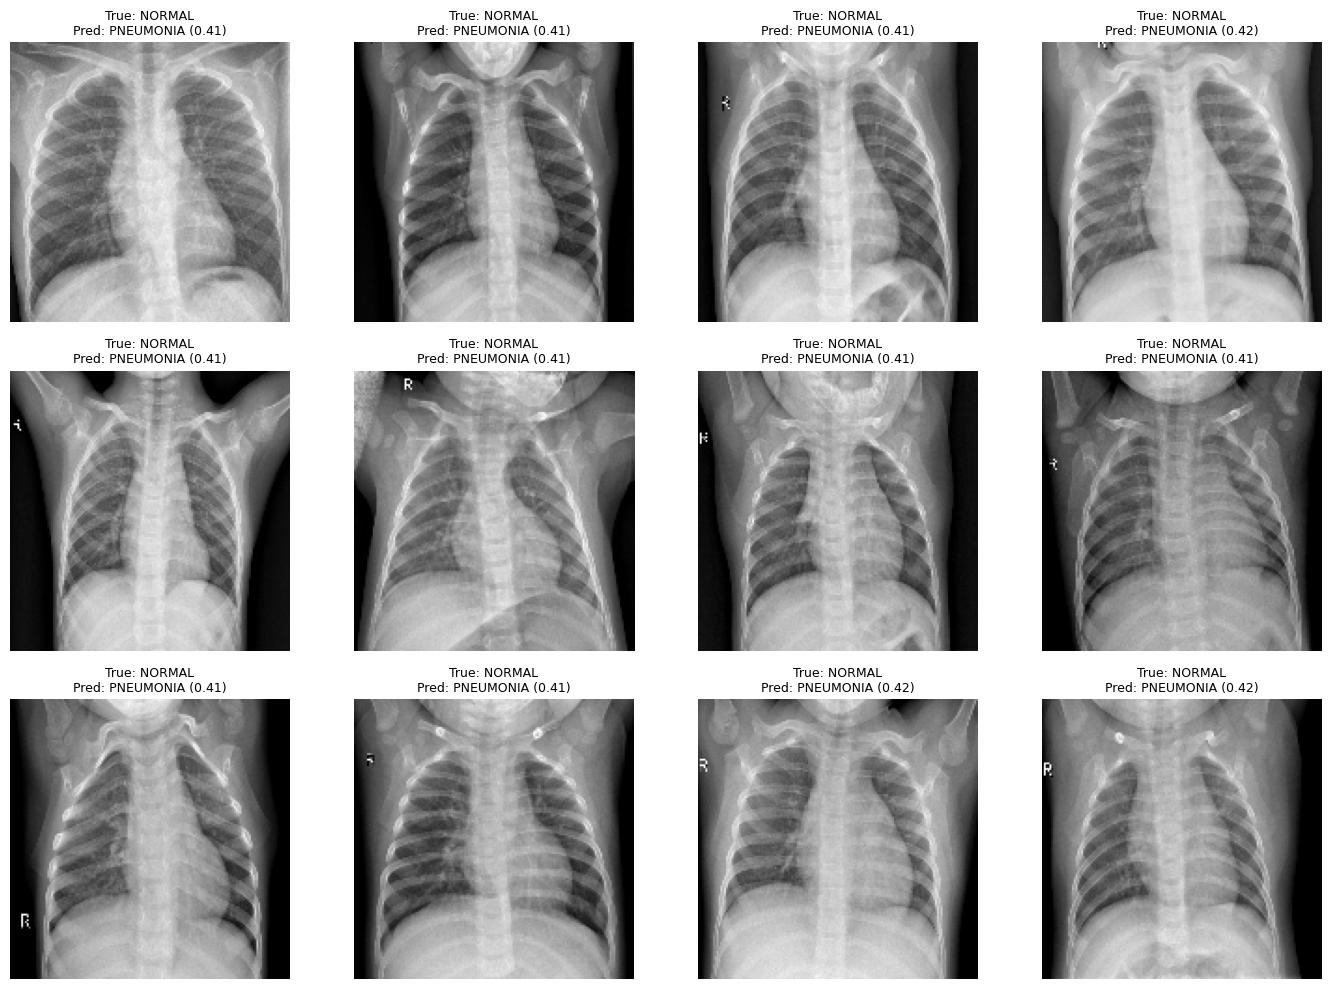

In [31]:
def get_misclassified(m, dataset, threshold=0.5, max_images=20):
    misclassified = []
    for images, labels in dataset:
        probs = m.predict(images, verbose=0).flatten()
        preds = (probs >= threshold).astype(int)
        true_lb = labels.numpy().flatten().astype(int)
        for i in range(len(true_lb)):
            if preds[i] != true_lb[i]:
                misclassified.append((images[i].numpy(), true_lb[i], preds[i], probs[i]))
            if len(misclassified) >= max_images:
                return misclassified
    return misclassified

misclassified_samples = get_misclassified(model, test_ds, threshold=CUSTOM_CNN_THRESHOLD, max_images=12)
print(f"Found {len(misclassified_samples)} misclassified samples shown below (need >=10 for Task 9)")

plt.figure(figsize=(14, 10))
for i, (img, true_lb, pred_lb, prob) in enumerate(misclassified_samples):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"True: {class_names[true_lb]}\nPred: {class_names[pred_lb]} ({prob:.2f})", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/results/misclassified_examples.png", dpi=150)
plt.show()

**For each misclassified image above, note in your report:**
- Was the true label NORMAL predicted as PNEUMONIA (false positive), or vice versa (false negative)?
- Was the model's probability close to the threshold (uncertain) or confidently wrong?
- Any visible reason: low contrast, unusual positioning, artifacts (tubes/wires), partial view?
- Do false negatives or false positives dominate — and what does that imply clinically (missing pneumonia is usually worse than a false alarm)?

## 12. Save all artifacts to Drive

In [32]:
import os

# On Kaggle, everything written to /kaggle/working/ is automatically preserved
# as the notebook's Output once you click "Save Version" -> "Save & Run All"
# (top right of the editor). No manual copy step is needed here.

print("Files ready in /kaggle/working/results:")
print(sorted(os.listdir("/kaggle/working/results")))
print("\nNow click 'Save Version' -> 'Save & Run All' to persist everything permanently.")


Files ready in /kaggle/working/results:
['ablation_results.csv', 'confusion_matrix_best_model.png', 'custom_cnn_20260914_124651.keras', 'custom_cnn_FINAL.keras', 'custom_cnn_curves_20260914_124651.png', 'custom_cnn_prob_histogram.png', 'data_volume_curve.png', 'data_volume_results.csv', 'grid_search_results.csv', 'history_20260914_124651.csv', 'misclassified_examples.png', 'model_comparison.csv', 'patience_ablation.csv', 'resnet50_finetuned_best.keras', 'resnet50_frozen_best.keras', 'roc_curves_all_models.png', 'sample_predictions.png', 'transfer_models_curves.png', 'vgg16_finetuned_best.keras', 'vgg16_frozen_best.keras']

Now click 'Save Version' -> 'Save & Run All' to persist everything permanently.
